<a href="https://colab.research.google.com/github/riyamehta12/speech_impairement_recognition/blob/main/aiml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install librosa
!pip install openai-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.5/800.5 kB 8.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s e

Enter paths to audio files (comma-separated): /content/Audio2.wav


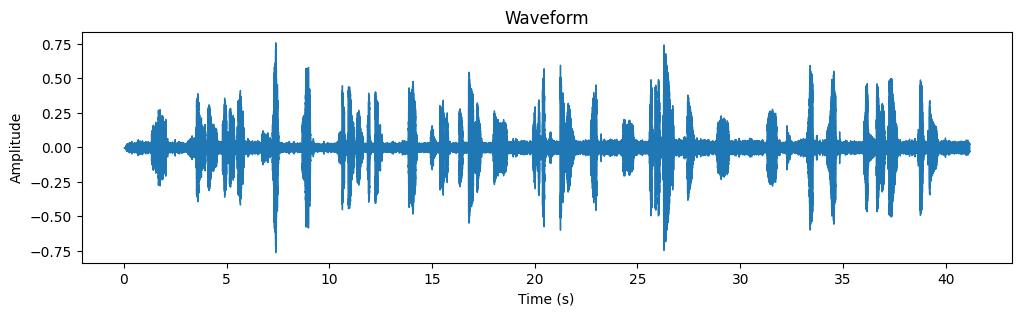

/usr/local/lib/python3.11/dist-packages/whisper/transcribe.py:126: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")



📄 Transcript (lowercased):  so, this is what do you call what? so, this is a test for speech impairment detect causes what? what do you call what? what what what do you call that thing?

🧠 NLP + Audio Features for /content/Audio2.wav:
  - Pitch Variability: 698.8400268554688 Hz
  - Average Pitch: 983.8400268554688 Hz
  - Repetitions: 2
  - Fillers: 5
  - Pauses: 3
  - Speech Rate: 46.66 WPM



<ipython-input-5-8e887dadbee9>:124: FutureWarning: get_duration() keyword argument 'filename' has been renamed to 'path' in version 0.10.0.
	This alias will be removed in version 1.0.
  duration = librosa.get_duration(filename=path.strip())  # Get duration


NameError: name 'GridSearchCV' is not defined

In [5]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import whisper
import re
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

# ========== INPUT ==========
audio_paths = input("Enter paths to audio files (comma-separated): ").split(',')

# ========== AUDIO LOADING & VISUALIZATION ==========
def load_audio(file_path):
    y, sr = librosa.load(file_path.strip(), sr=None)
    duration = librosa.get_duration(y=y, sr=sr)
    return y, sr, duration

def plot_waveform(y, sr):
    plt.figure(figsize=(12, 3))
    librosa.display.waveshow(y, sr=sr)
    plt.title("Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.show()

# ========== AUDIO FEATURE EXTRACTION ==========
def extract_audio_features(y, sr):
    pitches, magnitudes = librosa.piptrack(y=y, sr=sr)
    voiced = pitches[magnitudes > 0]
    return {
        "rms": np.mean(librosa.feature.rms(y=y)),
        "zcr": np.mean(librosa.feature.zero_crossing_rate(y)),
        "spectral_centroid": np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)),
        "spectral_bandwidth": np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr)),
        "spectral_rolloff": np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)),
        "spectral_contrast": np.mean(librosa.feature.spectral_contrast(y=y, sr=sr)),
        "mfcc": np.mean(librosa.feature.mfcc(y=y, sr=sr)),
        "average_pitch": np.mean(voiced),
        "pitch_variability": np.std(voiced)
    }

# ========== NLP FEATURE EXTRACTION ==========
filler_words = [
    "um", "uh", "ah", "hmm", "like", "you know", "so", "well", "actually",
    "basically", "right", "okay", "i mean", "sort of", "kind of", "what do you call"
]
filler_pattern = re.compile(r"\b(" + "|".join([f"{fw}+" for fw in filler_words]) + r")\b", flags=re.IGNORECASE)

def count_fillers(text):
    return len(filler_pattern.findall(text))

def detect_repetitions(text, window=3):
    words = text.split()
    rep = Counter()
    for i in range(len(words) - window + 1):
        for j in range(i+1, i+window):
            if words[i] == words[j]:
                rep[words[i]] += 1
                break
    return sum(rep.values())

def detect_pauses(segments, threshold=0.5):
    return [1 for i in range(len(segments) - 1)
            if segments[i+1]["start"] - segments[i]["end"] > threshold]

# ========== COMBINE FEATURES ==========
def extract_all_features(file_path):
    y, sr, duration = load_audio(file_path)
    plot_waveform(y, sr)

    audio_feats = extract_audio_features(y, sr)

    model = whisper.load_model("base")
    result = model.transcribe(file_path, word_timestamps=True)
    text = result['text'].lower()
    segments = result.get("segments", [])

    num_words = len(text.split())
    speech_rate = (num_words / duration) * 60

    # NLP metrics
    fillers = count_fillers(text)
    repetitions = detect_repetitions(text)
    pauses = sum(detect_pauses(segments))

    print(f"\n📄 Transcript (lowercased): {text}\n")
    print(f"🧠 NLP + Audio Features for {file_path.strip()}:")
    print(f"  - Pitch Variability: {round(audio_feats['pitch_variability'], 2)} Hz")
    print(f"  - Average Pitch: {round(audio_feats['average_pitch'], 2)} Hz")
    print(f"  - Repetitions: {repetitions}")
    print(f"  - Fillers: {fillers}")
    print(f"  - Pauses: {pauses}")
    print(f"  - Speech Rate: {round(speech_rate, 2)} WPM\n")

    return {
        **audio_feats,
        "num_filler_words": fillers,
        "num_repetitions": repetitions,
        "num_pauses": pauses,
        "speech_rate_wpm": speech_rate
    }

# ========== MANUAL SCORING (TIGHTER RULES) ==========
def anomaly_score(f, duration):
    score = 0
    if f['pitch_variability'] > 80: score += 1
    if f['num_filler_words'] > 3: score += 1
    if f['num_repetitions'] > 1: score += 1
    if f['num_pauses'] > 2: score += 1
    if f['speech_rate_wpm'] < 110: score += 1

    # Calculate anomalies per minute
    anomalies_per_minute = score / (duration / 60)
    return score, anomalies_per_minute

# ========== RUN FEATURE EXTRACTION & SCORING ==========
feature_list = []
for path in audio_paths:
    features = extract_all_features(path.strip())
    duration = librosa.get_duration(filename=path.strip())  # Get duration
    features['anomaly_score'], features['anomalies_per_minute'] = anomaly_score(features, duration)
    feature_list.append(features)

df = pd.DataFrame(feature_list)

# ========== MACHINE LEARNING (with hyperparameter tuning and IsolationForest) ==========
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['pitch_variability', 'num_filler_words', 'num_repetitions', 'num_pauses', 'speech_rate_wpm']])

# Hyperparameter Tuning for OneClassSVM
param_grid = {'nu': [0.1, 0.2, 0.3], 'kernel': ['rbf', 'poly', 'sigmoid'], 'gamma': ['scale', 'auto']}
svm = GridSearchCV(OneClassSVM(), param_grid, cv=3)  # 3-fold cross-validation
svm.fit(X_scaled)
df['svm_anomaly'] = svm.predict(X_scaled)  # -1 = anomaly

# IsolationForest for Anomaly Detection
iso_forest = IsolationForest(contamination='auto', random_state=0)
df['iso_forest_anomaly'] = iso_forest.fit_predict(X_scaled)  # -1 = anomaly

# Decision Tree (no changes)
tree = DecisionTreeClassifier(max_depth=3, random_state=0)
tree.fit(X_scaled, df['anomaly_score'] > 2)
df['tree_anomaly'] = tree.predict(X_scaled)

# ========== FINAL VERDICT ==========
df['final_verdict'] = (df['anomaly_score'] > 2) | (df['svm_anomaly'] == -1) | (df['iso_forest_anomaly'] == -1) | (df['tree_anomaly'])
summary = df[['anomaly_score', 'anomalies_per_minute', 'svm_anomaly', 'iso_forest_anomaly', 'tree_anomaly', 'final_verdict']]
summary.index = [path.strip() for path in audio_paths]
print("\n📊 Final Risk Summary:")
print(summary.to_string())

Enter paths to audio files (comma-separated): /content/Audio2.wav


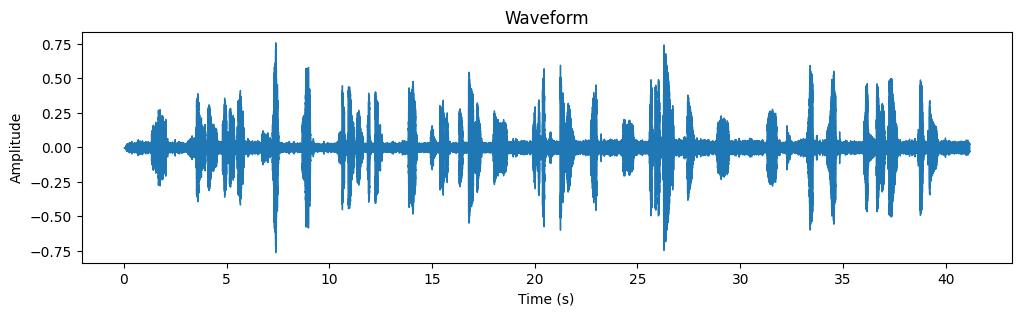

/usr/local/lib/python3.11/dist-packages/whisper/transcribe.py:126: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")



📄 Transcript (lowercased):  so, this is what do you call what? so, this is a test for speech impairment detect causes what? what do you call what? what what what do you call that thing?

🧠 NLP + Audio Features for /content/Audio2.wav:
  - Pitch Variability: 698.8400268554688 Hz
  - Average Pitch: 983.8400268554688 Hz
  - Repetitions: 2
  - Fillers: 5
  - Pauses: 3
  - Speech Rate: 46.66 WPM



<ipython-input-6-38639c0bb55a>:125: FutureWarning: get_duration() keyword argument 'filename' has been renamed to 'path' in version 0.10.0.
	This alias will be removed in version 1.0.
  duration = librosa.get_duration(filename=path.strip())  # Get duration



📊 Final Risk Summary:
                     anomaly_score  anomalies_per_minute  svm_anomaly  iso_forest_anomaly  tree_anomaly  final_verdict
/content/Audio2.wav              5              7.290047           -1                   1          True           True


In [6]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import whisper
import re
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import IsolationForest
import pandas as pd

# ========== INPUT ==========
audio_paths = input("Enter paths to audio files (comma-separated): ").split(',')

# ========== AUDIO LOADING & VISUALIZATION ==========
def load_audio(file_path):
    y, sr = librosa.load(file_path.strip(), sr=None)
    duration = librosa.get_duration(y=y, sr=sr)
    return y, sr, duration

def plot_waveform(y, sr):
    plt.figure(figsize=(12, 3))
    librosa.display.waveshow(y, sr=sr)
    plt.title("Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.show()

# ========== AUDIO FEATURE EXTRACTION ==========
def extract_audio_features(y, sr):
    pitches, magnitudes = librosa.piptrack(y=y, sr=sr)
    voiced = pitches[magnitudes > 0]
    return {
        "rms": np.mean(librosa.feature.rms(y=y)),
        "zcr": np.mean(librosa.feature.zero_crossing_rate(y)),
        "spectral_centroid": np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)),
        "spectral_bandwidth": np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr)),
        "spectral_rolloff": np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)),
        "spectral_contrast": np.mean(librosa.feature.spectral_contrast(y=y, sr=sr)),
        "mfcc": np.mean(librosa.feature.mfcc(y=y, sr=sr)),
        "average_pitch": np.mean(voiced),
        "pitch_variability": np.std(voiced)
    }

# ========== NLP FEATURE EXTRACTION ==========
filler_words = [
    "um", "uh", "ah", "hmm", "like", "you know", "so", "well", "actually",
    "basically", "right", "okay", "i mean", "sort of", "kind of", "what do you call"
]
filler_pattern = re.compile(r"\b(" + "|".join([f"{fw}+" for fw in filler_words]) + r")\b", flags=re.IGNORECASE)

def count_fillers(text):
    return len(filler_pattern.findall(text))

def detect_repetitions(text, window=3):
    words = text.split()
    rep = Counter()
    for i in range(len(words) - window + 1):
        for j in range(i+1, i+window):
            if words[i] == words[j]:
                rep[words[i]] += 1
                break
    return sum(rep.values())

def detect_pauses(segments, threshold=0.5):
    return [1 for i in range(len(segments) - 1)
            if segments[i+1]["start"] - segments[i]["end"] > threshold]

# ========== COMBINE FEATURES ==========
def extract_all_features(file_path):
    y, sr, duration = load_audio(file_path)
    plot_waveform(y, sr)

    audio_feats = extract_audio_features(y, sr)

    model = whisper.load_model("base")
    result = model.transcribe(file_path, word_timestamps=True)
    text = result['text'].lower()
    segments = result.get("segments", [])

    num_words = len(text.split())
    speech_rate = (num_words / duration) * 60

    # NLP metrics
    fillers = count_fillers(text)
    repetitions = detect_repetitions(text)
    pauses = sum(detect_pauses(segments))

    print(f"\n📄 Transcript (lowercased): {text}\n")
    print(f"🧠 NLP + Audio Features for {file_path.strip()}:")
    print(f"  - Pitch Variability: {round(audio_feats['pitch_variability'], 2)} Hz")
    print(f"  - Average Pitch: {round(audio_feats['average_pitch'], 2)} Hz")
    print(f"  - Repetitions: {repetitions}")
    print(f"  - Fillers: {fillers}")
    print(f"  - Pauses: {pauses}")
    print(f"  - Speech Rate: {round(speech_rate, 2)} WPM\n")

    return {
        **audio_feats,
        "num_filler_words": fillers,
        "num_repetitions": repetitions,
        "num_pauses": pauses,
        "speech_rate_wpm": speech_rate
    }

# ========== MANUAL SCORING (TIGHTER RULES) ==========
def anomaly_score(f, duration):
    score = 0
    if f['pitch_variability'] > 80: score += 1
    if f['num_filler_words'] > 3: score += 1
    if f['num_repetitions'] > 1: score += 1
    if f['num_pauses'] > 2: score += 1
    if f['speech_rate_wpm'] < 110: score += 1

    # Calculate anomalies per minute
    anomalies_per_minute = score / (duration / 60)
    return score, anomalies_per_minute

# ========== RUN FEATURE EXTRACTION & SCORING ==========
feature_list = []
for path in audio_paths:
    features = extract_all_features(path.strip())
    duration = librosa.get_duration(filename=path.strip())  # Get duration
    features['anomaly_score'], features['anomalies_per_minute'] = anomaly_score(features, duration)
    feature_list.append(features)

df = pd.DataFrame(feature_list)

# ========== MACHINE LEARNING (with general models) ==========
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['pitch_variability', 'num_filler_words', 'num_repetitions', 'num_pauses', 'speech_rate_wpm']])

# OneClassSVM with default parameters
svm = OneClassSVM()
svm.fit(X_scaled)
df['svm_anomaly'] = svm.predict(X_scaled)  # -1 = anomaly

# IsolationForest with default parameters
iso_forest = IsolationForest(random_state=0)
df['iso_forest_anomaly'] = iso_forest.fit_predict(X_scaled)  # -1 = anomaly

# Decision Tree with default parameters
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_scaled, df['anomaly_score'] > 2)
df['tree_anomaly'] = tree.predict(X_scaled)

# ========== FINAL VERDICT ==========
df['final_verdict'] = (df['anomaly_score'] > 2) | (df['svm_anomaly'] == -1) | (df['iso_forest_anomaly'] == -1) | (df['tree_anomaly'])
summary = df[['anomaly_score', 'anomalies_per_minute', 'svm_anomaly', 'iso_forest_anomaly', 'tree_anomaly', 'final_verdict']]
summary.index = [path.strip() for path in audio_paths]
print("\n📊 Final Risk Summary:")
print(summary.to_string())